# Módulo 3 - Prática de Visualização e Primeira Versão de EDA

Este notebook aproxima o curso de uma análise exploratória real, com perguntas e gráficos escolhidos para respondê-las.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')

escola = pd.read_csv('../../datasets/escolhidos_ava_2/EquipeA_escola.csv')
cidades = pd.read_csv('../../datasets/escolhidos_ava_2/EquipeE_cidades.csv')


---
## 1. Pergunta inicial com dataset simples

**Pergunta:** o desempenho escolar parece acompanhar a frequência?


In [2]:
# Primeiro criamos a coluna de situação para enriquecer a visualização.
escola['situacao'] = escola.apply(
    lambda linha: 'Aprovado' if linha['nota'] >= 7 and linha['frequencia'] >= 75 else 'Reprovado',
    axis=1
)


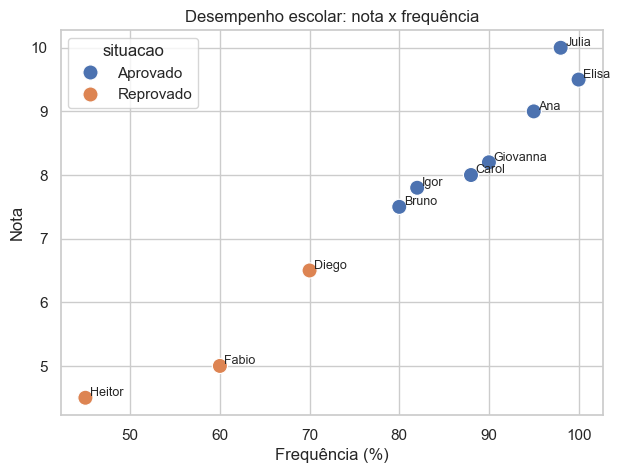

In [3]:
# Gráfico de dispersão com anotação dos nomes.
plt.figure(figsize=(7, 5))
sns.scatterplot(data=escola, x='frequencia', y='nota', hue='situacao', s=120)
for _, linha in escola.iterrows():
    plt.text(linha['frequencia'] + 0.5, linha['nota'] + 0.03, linha['nome'], fontsize=9)
plt.title('Desempenho escolar: nota x frequência')
plt.xlabel('Frequência (%)')
plt.ylabel('Nota')
plt.show()


Leitura do gráfico: os alunos aprovados se concentram na região de notas e frequências mais altas, o que reforça a utilidade desse tipo de visualização para identificar padrões rapidamente.


---
## 2. Recorte analítico com cidades

**Problema formulado:** quais indicadores ajudam a enxergar diferenças entre porte populacional, desenvolvimento humano e estrutura urbana/turística?


In [4]:
# Selecionamos apenas as colunas necessárias para a primeira versão da EDA.
cols = [
    'CITY', 'STATE', 'CAPITAL', 'ESTIMATED_POP', 'GDP_CAPITA', 'IDHM',
    'HOTELS', 'BEDS', 'Cars', 'Motorcycles', 'RURAL_URBAN'
]
eda = cidades[cols].copy()
eda = eda.rename(columns={
    'CITY': 'cidade',
    'STATE': 'uf',
    'CAPITAL': 'capital',
    'ESTIMATED_POP': 'populacao',
    'GDP_CAPITA': 'pib_per_capita',
    'IDHM': 'idhm',
    'HOTELS': 'hoteis',
    'BEDS': 'leitos',
    'Cars': 'carros',
    'Motorcycles': 'motos',
    'RURAL_URBAN': 'perfil_territorial'
})
eda['frota_total'] = eda['carros'] + eda['motos']
eda.head()


,cidade,uf,capital,populacao,pib_per_capita,idhm,hoteis,leitos,carros,motos,perfil_territorial,frota_total
0,Abadia De Goiás,GO,0,8583,20665.0,0.708,0,0,2158,1246,Urbano,3404
1,Abadia Dos Dourados,MG,0,6972,25592.0,0.689,0,0,2227,1142,Rural Adjacente,3369
2,Abadiânia,GO,0,19614,15628.0,0.689,1,34,2838,1426,Rural Adjacente,4264
3,Abaetetuba,PA,0,156292,8222.0,0.628,0,0,5277,25661,Urbano,30938
4,Abaeté,MG,0,23223,18250.0,0.698,0,0,6928,2953,Urbano,9881


---
## 3. Pergunta 1

**As capitais parecem ter IDHM mais alto?**


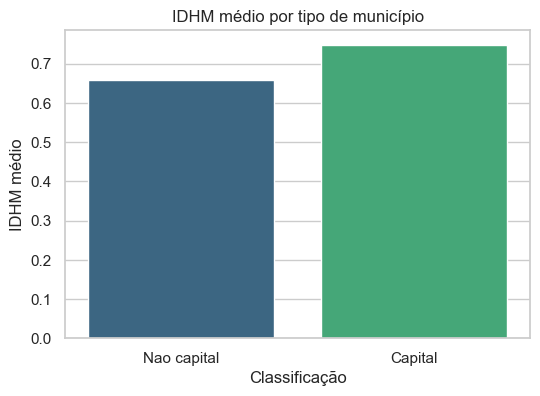

In [5]:
idhm_capitais = eda.groupby('capital', as_index=False)['idhm'].mean()
idhm_capitais['capital'] = idhm_capitais['capital'].map({0: 'Nao capital', 1: 'Capital'})

plt.figure(figsize=(6, 4))
sns.barplot(data=idhm_capitais, x='capital', y='idhm', hue='capital', legend=False, palette='viridis')
plt.title('IDHM médio por tipo de município')
plt.xlabel('Classificação')
plt.ylabel('IDHM médio')
plt.show()


No dataset, as capitais têm média de IDHM superior às demais cidades. Isso não prova causalidade, mas sugere uma diferença estrutural importante.


---
## 4. Pergunta 2

**Existe relação visual entre PIB per capita e IDHM?**


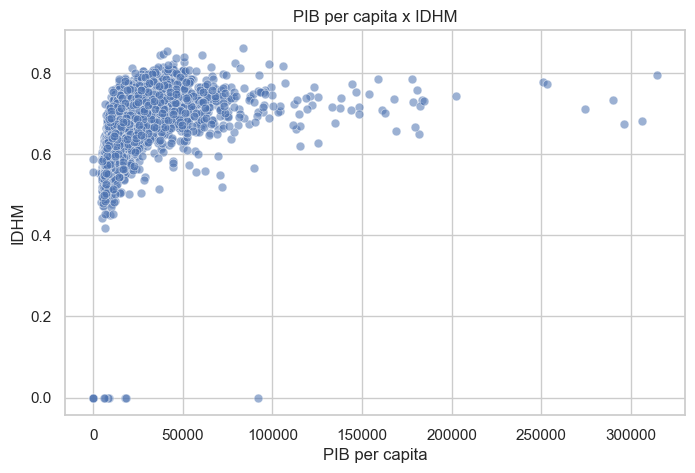

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=eda, x='pib_per_capita', y='idhm', alpha=0.55, s=40)
plt.title('PIB per capita x IDHM')
plt.xlabel('PIB per capita')
plt.ylabel('IDHM')
plt.show()


A nuvem de pontos mostra tendência positiva, mas com bastante dispersão. Em outras palavras, renda ajuda a explicar o IDHM, porém não sozinha.


---
## 5. Pergunta 3

**Quais cidades se destacam em estrutura hoteleira?**


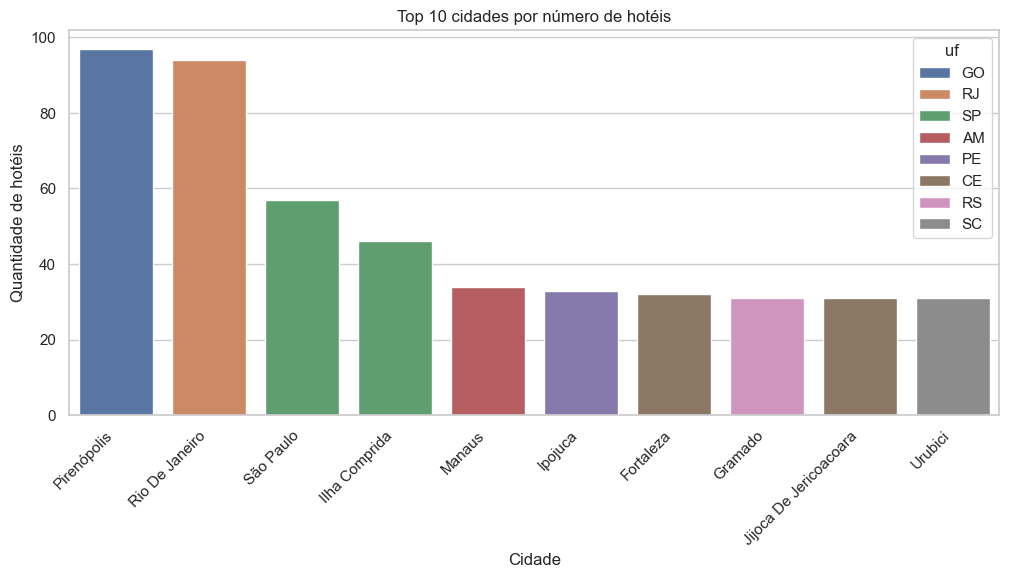

,cidade,uf,hoteis,leitos
3819,Pirenópolis,GO,97,2418
4175,Rio De Janeiro,RJ,94,13247
4997,São Paulo,SP,57,10022
2130,Ilha Comprida,SP,46,3053
2849,Manaus,AM,34,3401
2205,Ipojuca,PE,33,1454
1793,Fortaleza,CE,32,3135
1921,Gramado,RS,31,2166
2546,Jijoca De Jericoacoara,CE,31,647
5367,Urubici,SC,31,583


In [7]:
top_hoteis = eda.nlargest(10, 'hoteis')[['cidade', 'uf', 'hoteis', 'leitos']]

plt.figure(figsize=(12, 5))
sns.barplot(data=top_hoteis, x='cidade', y='hoteis', hue='uf', dodge=False)
plt.title('Top 10 cidades por número de hotéis')
plt.xlabel('Cidade')
plt.ylabel('Quantidade de hotéis')
plt.xticks(rotation=45, ha='right')
plt.show()

top_hoteis


Esse recorte ajuda a formular hipóteses sobre turismo, serviços e concentração de infraestrutura em alguns municípios específicos.


---
## 6. Pergunta 4

**Como o porte populacional se distribui entre os municípios com maior população?**


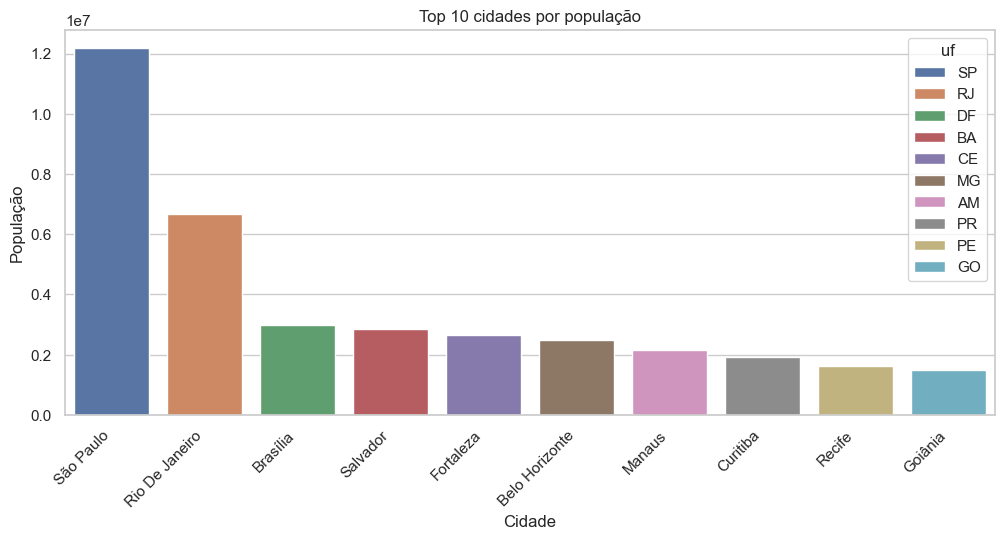

In [8]:
top_pop = eda.nlargest(10, 'populacao')[['cidade', 'uf', 'populacao']]

plt.figure(figsize=(12, 5))
sns.barplot(data=top_pop, x='cidade', y='populacao', hue='uf', dodge=False)
plt.title('Top 10 cidades por população')
plt.xlabel('Cidade')
plt.ylabel('População')
plt.xticks(rotation=45, ha='right')
plt.show()


---
## 7. Primeira versão do projeto de EDA

Com base no notebook, já ficam definidos os itens pedidos na entrega:
- **dataset escolhido:** `EquipeE_cidades.csv`;
- **problema formulado:** identificar padrões entre população, desenvolvimento humano, renda e infraestrutura urbana/turística;
- **perguntas norteadoras:**
  1. Capitais têm IDHM médio mais alto?
  2. PIB per capita e IDHM se relacionam visualmente?
  3. Quais cidades lideram em estrutura hoteleira?
  4. Quais municípios concentram as maiores populações?
